In [6]:
import datetime
import glob
import os
import re
import sys

import lseg.data as ld
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "./src")
%load_ext autoreload
%autoreload 2

from pathlib import Path
from os.path import basename, join
from datetime import datetime as dt
from lseg.data.content import historical_pricing
from lseg.data.content.historical_pricing import Intervals

from comp_iv.config import ROOT, DATA, OUTPUTS, VCS
from comp_iv.index_calculation import (
    _detect_missing_trade_days, 
    _get_Tp1,
    _get_Tm1,
    idx_calc, 
    main
    )

ld.open_session()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<lseg.data.session.Definition object at 0x24962331b10 {name='workspace'}>

In [7]:
files = glob.glob(join(DATA, "*.csv"))

all_idx = []
for x in files:
    m = re.search(r"closecomposition_([a-z]+)_\d+\.csv$", basename(x))
    if m:
        all_idx.append(m.group(1))

all_idx = list(set(all_idx))
all_idx_rt = [f".{x.upper()}" for x in all_idx]

all_idx, all_idx_rt

(['sxeimgp', 'sxeimggr', 'sxeimgv', 'sxeimgl', 'sxeimgr', 'sxeimggv'],
 ['.SXEIMGP', '.SXEIMGGR', '.SXEIMGV', '.SXEIMGL', '.SXEIMGR', '.SXEIMGGV'])

In [ ]:
# Unarchive

# import zipfile
# from pathlib import Path

# month_start = 201803
# month_end = 201812
# zip_files = []
# OUTPUT_TEMP = join(ROOT, "data_stoxx")

# while month_start <= month_end:
#     zip_files.append(f"C:/Users/lifre/Downloads/sxeimggv_{month_start}.zip")
#     month_start += 1

# def extract_zip_files(zip_files: list[str], output_dir: str) -> None:
#     output_path = Path(output_dir)
#     output_path.mkdir(parents=True, exist_ok=True)

#     for zip_file in zip_files:
#         zip_path = Path(zip_file)

#         if not zip_path.exists():
#             print(f"File not exist: {zip_path}")
#             continue

#         if not zipfile.is_zipfile(zip_path):
#             print(f"Not a valid zip path: {zip_path}")
#             continue

#         with zipfile.ZipFile(zip_path, "r") as zf:
#             zf.extractall(output_path)
            
# extract_zip_files(zip_files, OUTPUT_TEMP)

In [ ]:
# idx = "sxeimgl"

# def check_and_rename_file(csvpath: str) -> None:
#     csv_basename = basename(csvpath)
#     csv_date_raw = csv_basename.split("_")[-1].replace(".csv", "")
#     csv_date = dt.strptime(csv_date_raw, "%Y%m%d").date()

#     if csv_basename.startswith("close_"):
#         df = pd.read_csv(csvpath, sep=";", dtype={"Date": str})
#         df["Date"] = pd.to_datetime(df["Date"])
#         df_date = df["Date"].iloc[0].date()

#         if csv_date != df_date:
#             raise ValueError(
#                 f"Close file {csv_basename} date mismatch! {csv_date} {df_date}"
#             )

#         new_csvpath = csvpath.replace("close_", "closecomposition_")
#         os.rename(csvpath, new_csvpath)
#         print(f"{csv_basename} -> {basename(new_csvpath)}")

#     elif csv_basename.startswith("open_"):
#         df = pd.read_csv(csvpath, sep=";", dtype={"Next_Trading_Day": str})
#         df["Next_Trading_Day"] = pd.to_datetime(df["Next_Trading_Day"])
#         df_date = df["Next_Trading_Day"].iloc[0].date()
#         new_date_raw = _get_Tm1(idx, df_date).strftime("%Y%m%d")
#         new_csvpath = csvpath.replace("open_", "opencomposition_").replace(
#             csv_date_raw, new_date_raw
#         )
#         os.rename(csvpath, new_csvpath)
#         print(f"{csv_basename} -> {basename(new_csvpath)}")
          
# csvs = glob.glob(join(OUTPUT_TEMP, "*.csv"))

# for csv in csvs:
#     check_and_rename_file(csv)

In [ ]:
# csv_files_2 = glob.glob(join(OUTPUT_TEMP, "*.csv"))

# for csv in csv_files_2:
#     filename_date = basename(csv).split("_")[-1].replace(".csv", "")
#     filename_date: datetime.date =  dt.strptime(filename_date, "%Y%m%d").date()
    
#     with open(csv, "r") as f:
#         f.readline()
#         second_line = f.readline()
#         secondline_date: str = second_line.split(";")[0]
#         secondline_date: datetime.date = dt.strptime(secondline_date, "%Y-%m-%d").date()
        
#         if basename(csv).startswith("open_") or basename(csv).startswith("close_"):
#             raise ValueError(basename(csv))
        
#         if basename(csv).startswith("closecomposition_"):
#             if filename_date != secondline_date:
#                 raise ValueError(f"Close: Filename date: {filename_date}, 2nd line date: {secondline_date}")
        
#         if basename(csv).startswith("opencomposition_"):
#             Tp1_filenamedate: datetime.date = _get_Tp1(idx, filename_date)
#             if Tp1_filenamedate != secondline_date:
#                 raise ValueError(f"Open: Next trading date of filename: {Tp1_filenamedate}, 2nd line date: {secondline_date}")
    
# print("Done")

Done


In [8]:
files = glob.glob(join(DATA, "*.csv"))
for f in files:
    if basename(f).endswith("20181231.csv"):
    # fpath = Path(f)
    # modified_date = datetime.datetime.fromtimestamp(fpath.stat().st_mtime).date()
    # if modified_date == datetime.date(2026, 5, 22):
        os.remove(f)
        print(f"removed {basename(f)}")

In [22]:
# IV Calc

for idx in all_idx:
    main(idx)

Finished: sxeimgp 20170330 -> 20181228
Finished: sxeimggr 20170330 -> 20181228
Finished: sxeimgv 20170330 -> 20181228
Finished: sxeimgl 20170330 -> 20181228
Finished: sxeimgr 20170330 -> 20181228
Finished: sxeimggv 20170330 -> 20181228


In [ ]:
# file_path = r"C:\Users\lifre\Downloads\comp_iv\outputs\sxeimgv_20170330_20180301.csv"

# df = pd.read_csv(file_path, sep=";")
# # df["ivdiff"] = df["Index Value EOD"] - df["IV Pre"]
# # df["divisordiff"] = df["Divisor Open T (from T-1)"] - df["Divisor Pre"]
# df["T"] = pd.to_datetime(df["T"])

# df[df["T"] == "2018-01-08"]

In [ ]:
# response = historical_pricing.summaries.Definition(
#     universe=all_idx_rt,
#     interval=Intervals.DAILY,
#     count=3000,
#     fields=["TRDPRC_1"],
# ).get_data()

# df2: pd.DataFrame = response.data.df
# df2

# df2.to_csv(join(ROOT, "rt_hist.csv"), sep=";", index=True)

In [15]:
df2 = pd.read_csv(join(ROOT, "rt_hist.csv"), sep=";", dtype={"Date": str})
df2["Date"] = pd.to_datetime(df2["Date"])

In [16]:
df2

,Date,.SXEIMGV,.SXEIMGL,.SXEIMGGR,.SXEIMGP,.SXEIMGR,.SXEIMGGV
0,2014-10-20,963.78,997.08,841.97,879.98,850.59,954.01
1,2014-10-21,977.36,1011.12,857.26,895.95,866.03,967.46
2,2014-10-22,977.36,1011.04,861.56,900.33,870.34,967.50
3,2014-10-23,983.47,1017.27,868.17,907.17,877.02,973.54
4,2014-10-24,988.34,1022.30,871.10,910.21,879.98,978.37
...,...,...,...,...,...,...,...
2995,2026-05-15,3665.00,3084.45,3740.63,2991.50,3554.54,3856.87
2996,2026-05-18,3665.25,3083.79,3737.36,2987.77,3551.13,3857.47
2997,2026-05-19,3657.13,3076.91,3743.73,2992.80,3557.16,3848.94
2998,2026-05-20,3697.92,3111.12,3777.87,3019.96,3589.56,3891.92


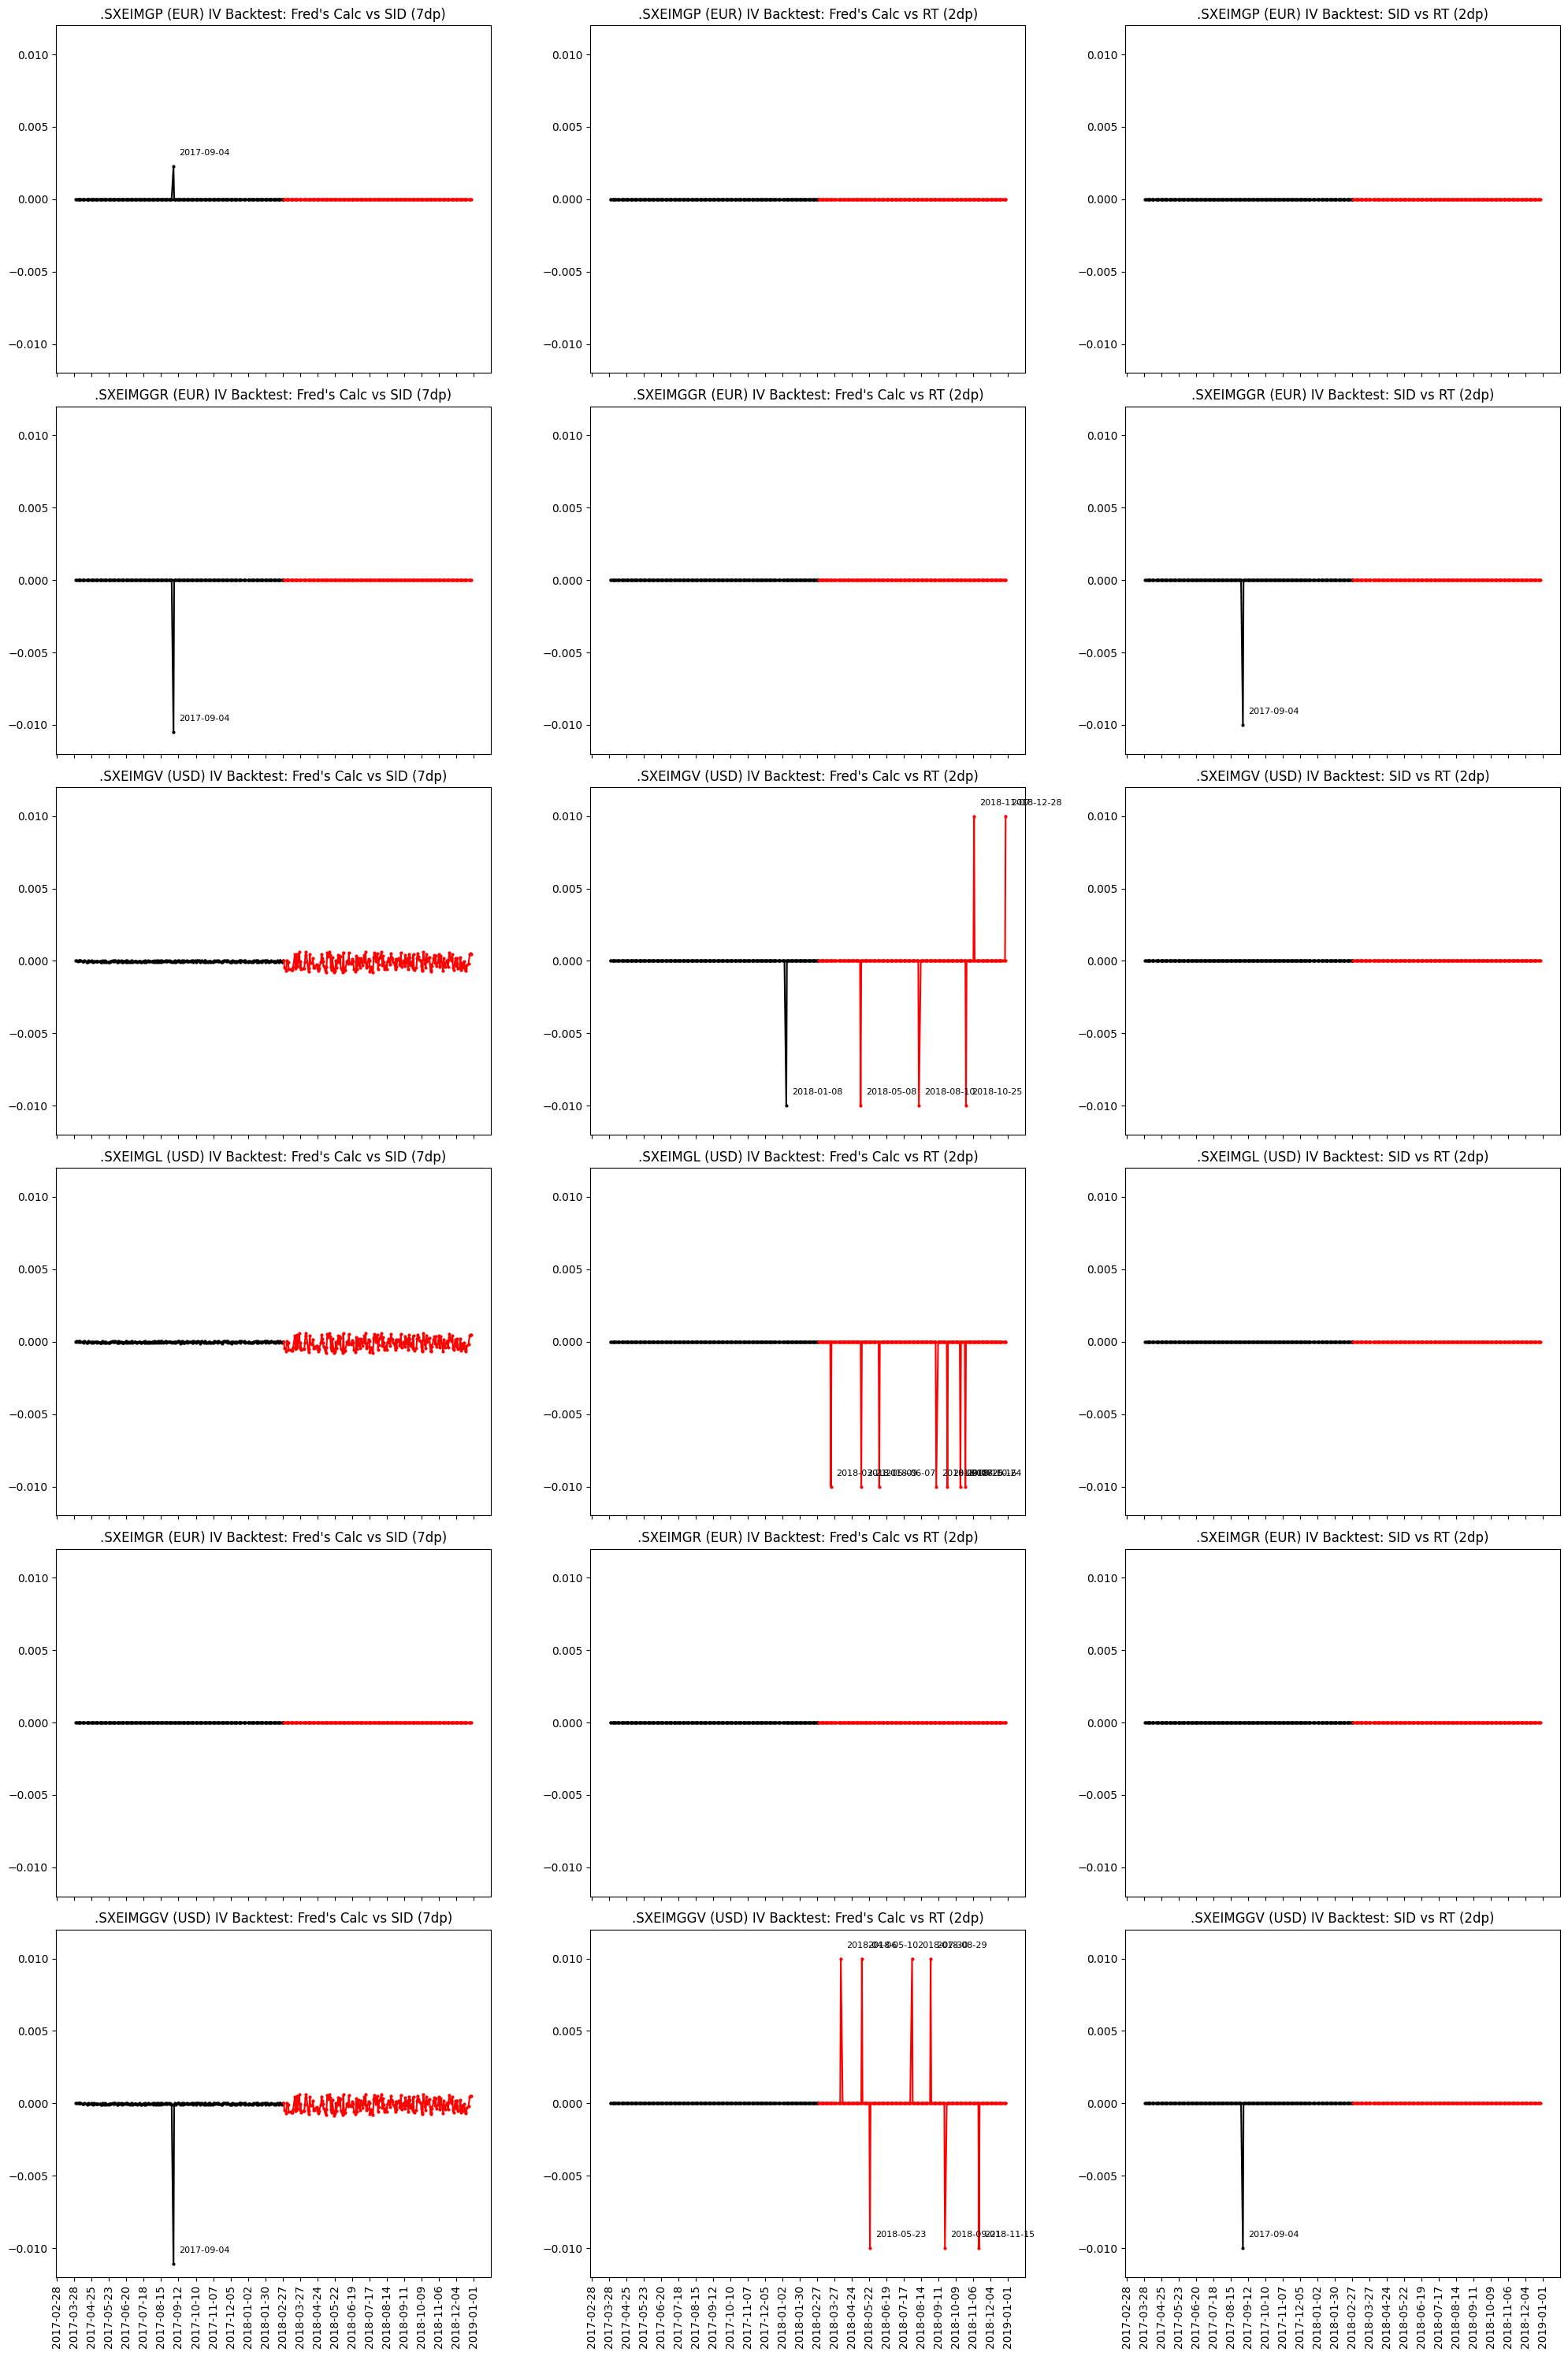

In [27]:
cutoff = pd.Timestamp("2018-03-01")
df2_indexed = df2.set_index("Date")

fig, axes = plt.subplots(6, 3, figsize=(20, 30), sharex=True)

for i, idx in enumerate(all_idx):
    file_path = rf"C:\Users\lifre\Downloads\comp_iv\outputs\{idx}_20170330_20181228.csv"
    df = pd.read_csv(file_path, sep=";")

    df["T"] = pd.to_datetime(df["T"])

    currency = VCS[VCS["Symbol"] == idx.upper()]["Curr"].values[0]
    idx_rt = f".{idx.upper()}"

    dftemp = df[["T", "Index Value EOD", "IV Pre"]].copy()
    dftemp["IV RT"] = dftemp["T"].map(df2_indexed[idx_rt])

    dftemp["ivdiff_calc_sid"] = dftemp["Index Value EOD"] - dftemp["IV Pre"]
    dftemp["ivdiff_calc_rt"] = round(dftemp["Index Value EOD"], 2) - dftemp["IV RT"]
    dftemp["ivdiff_sid_rt"] = dftemp["IV RT"] - round(dftemp["IV Pre"], 2)
    
    ax_sid = axes[i, 0]
    ax_rt = axes[i, 1]
    ax_sidrt = axes[i, 2]

    mask_red = dftemp["T"] >= cutoff
    mask_black = dftemp["T"] < cutoff

    # SID
    ax_sid.plot(
        dftemp.loc[mask_black, "T"],
        dftemp.loc[mask_black, "ivdiff_calc_sid"],
        marker="o",
        markersize=2,
        color="black",
    )
    ax_sid.plot(
        dftemp.loc[mask_red, "T"],
        dftemp.loc[mask_red, "ivdiff_calc_sid"],
        marker="o",
        markersize=2,
        color="red",
    )
    ax_sid.set_title(f"{idx_rt} ({currency}) IV Backtest: Fred's Calc vs SID (7dp)")
    ax_sid.set_ylim(-0.012, 0.012)

    # RT
    ax_rt.plot(
        dftemp.loc[mask_black, "T"],
        dftemp.loc[mask_black, "ivdiff_calc_rt"],
        marker="o",
        markersize=2,
        color="black",
    )
    ax_rt.plot(
        dftemp.loc[mask_red, "T"],
        dftemp.loc[mask_red, "ivdiff_calc_rt"],
        marker="o",
        markersize=2,
        color="red",
    )
    ax_rt.set_title(f"{idx_rt} ({currency}) IV Backtest: Fred's Calc vs RT (2dp)")
    ax_rt.set_ylim(-0.012, 0.012)

    # SID vs RT
    ax_sidrt.plot(
        dftemp.loc[mask_black, "T"],
        dftemp.loc[mask_black, "ivdiff_sid_rt"],
        marker="o",
        markersize=2,
        color="black",
    )
    ax_sidrt.plot(
        dftemp.loc[mask_red, "T"],
        dftemp.loc[mask_red, "ivdiff_sid_rt"],
        marker="o",
        markersize=2,
        color="red",
    )
    ax_sidrt.set_title(f"{idx_rt} ({currency}) IV Backtest: SID vs RT (2dp)")
    ax_sidrt.set_ylim(-0.012, 0.012)

    locator = mdates.WeekdayLocator(interval=4)
    formatter = mdates.DateFormatter("%Y-%m-%d")

    for ax in [ax_sid, ax_rt, ax_sidrt]:
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", rotation=90)

    # annotate SID
    mask_sid = dftemp["ivdiff_calc_sid"].abs() > 0.001
    for _, row in dftemp.loc[mask_sid, ["T", "ivdiff_calc_sid"]].iterrows():
        ax_sid.annotate(
            row["T"].strftime("%Y-%m-%d"),
            xy=(row["T"], row["ivdiff_calc_sid"]),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            color="black",
        )

    # annotate RT
    mask_rt = dftemp["ivdiff_calc_rt"].abs() > 0.001
    for _, row in dftemp.loc[mask_rt, ["T", "ivdiff_calc_rt"]].iterrows():
        ax_rt.annotate(
            row["T"].strftime("%Y-%m-%d"),
            xy=(row["T"], row["ivdiff_calc_rt"]),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            color="black",
        )

    # annotate SID vs RT
    mask_sidrt = dftemp["ivdiff_sid_rt"].abs() > 0.001
    for _, row in dftemp.loc[mask_sidrt, ["T", "ivdiff_sid_rt"]].iterrows():
        ax_sidrt.annotate(
            row["T"].strftime("%Y-%m-%d"),
            xy=(row["T"], row["ivdiff_sid_rt"]),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            color="black",
        )

plt.tight_layout()
plt.show()

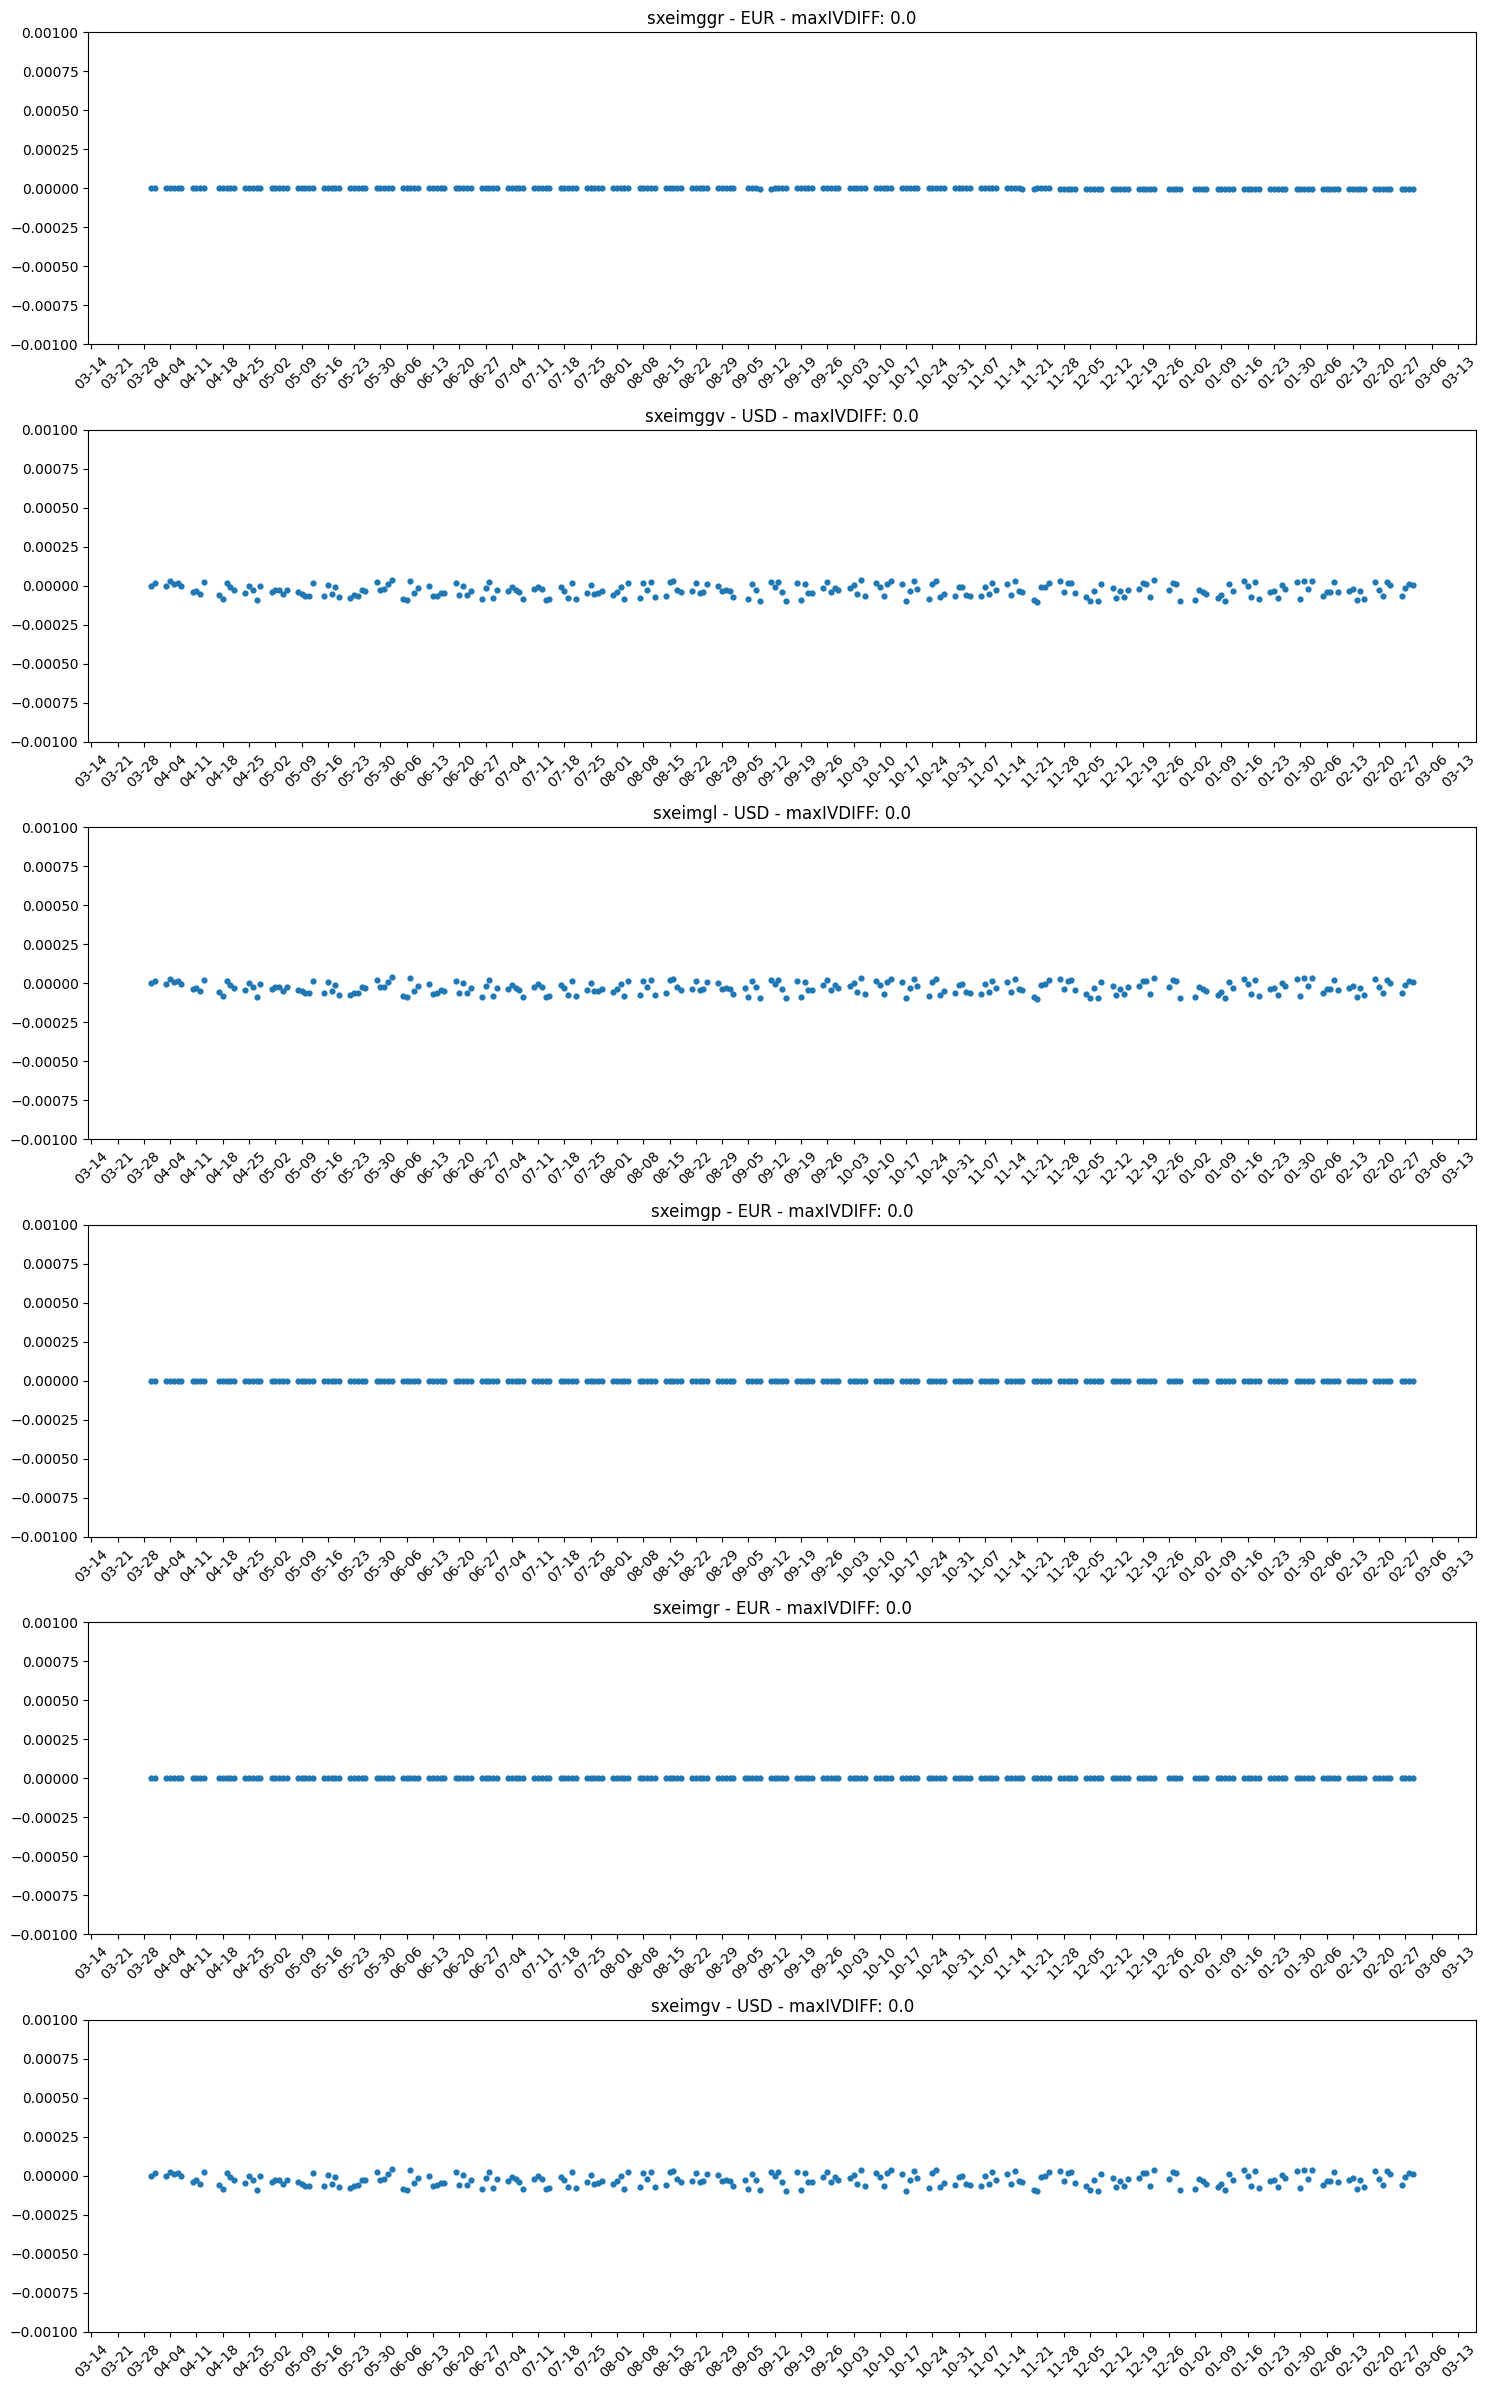

In [ ]:
csv_files = glob.glob(os.path.join(OUTPUTS, "*.csv"))

fig, axes = plt.subplots(
    nrows=len(csv_files), ncols=1, figsize=(15, 4 * len(csv_files)), sharex=False
)

if len(csv_files) == 1:
    axes = [axes]

for ax, file in zip(axes, csv_files):
    df = pd.read_csv(file, sep=";")
    df["ivdiff"] = df["Index Value EOD"] - df["IV Pre"]
    df["divisordiff"] = df["Divisor Open T (from T-1)"] - df["Divisor Pre"]
    dfpre = df.copy()
    dfpre["T"] = pd.to_datetime(dfpre["T"])
    ax.scatter(dfpre["T"], dfpre["ivdiff"], s=12)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(axis="x", rotation=45)
    title = os.path.basename(file).split("_")[0]
    currency = VCS[VCS["Symbol"] == title.upper()]["Curr"].values[0]
    max_ivdiff = round(max(df["ivdiff"]), 2)
    ax.set_title(f"{title} - {currency} - maxIVDIFF: {max_ivdiff}")
    ax.set_ylim(-0.001, 0.001)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()